# Hierarchical Clustering

- Cluster flu-related terms based on correlations between time series for each location
- Run the script for each location
- Save individual terms with <= 30% of zeros into a text file, they will be used as individual predictors
- Discard terms with > 99%
- Perform hierarchical clustering
- Find the optimal number of clusters based on the Elbow
- Save clusters into a text file
- Large clusters are further divided

**Notes**: 
- The script is designed to run on a single location at a time. Change the location with `filename = files[1]`, as we have one csv file per location.
- `num_clusters` is defined by the Elbow method with the `kneedle` algorithm, but can be adjusted manually based on the visualization of the Elbow plot. 

In [14]:
# importing necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, set_link_color_palette
from scipy.spatial.distance import squareform
from kneed import KneeLocator

In [16]:
# reading data for each location
directory = "../../data/01_raw/individual_merged_trends/"
# sorting file names alphabetically
files = sorted(os.listdir(directory))
files = sorted([file for file in files if file.endswith('.csv')])
print(len(files), 'csv files')

53 csv files


## For one file

US-AK


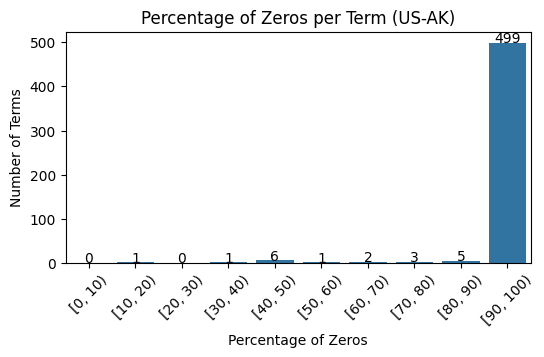

Terms with <30% of zeros ['china']
Number of features: 65


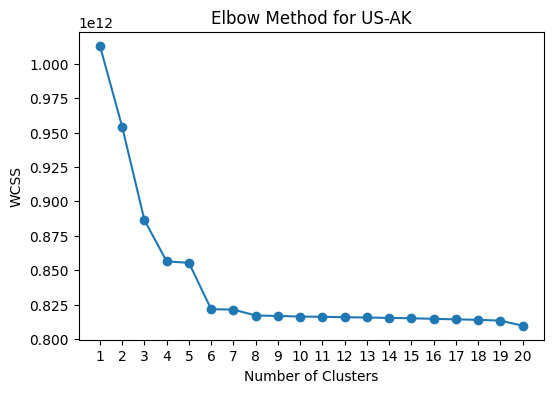

The elbow point is at cluster number: 6
                 0   1   2   3
Cluster          1   2   3   4
Number of terms  5  34  12  14


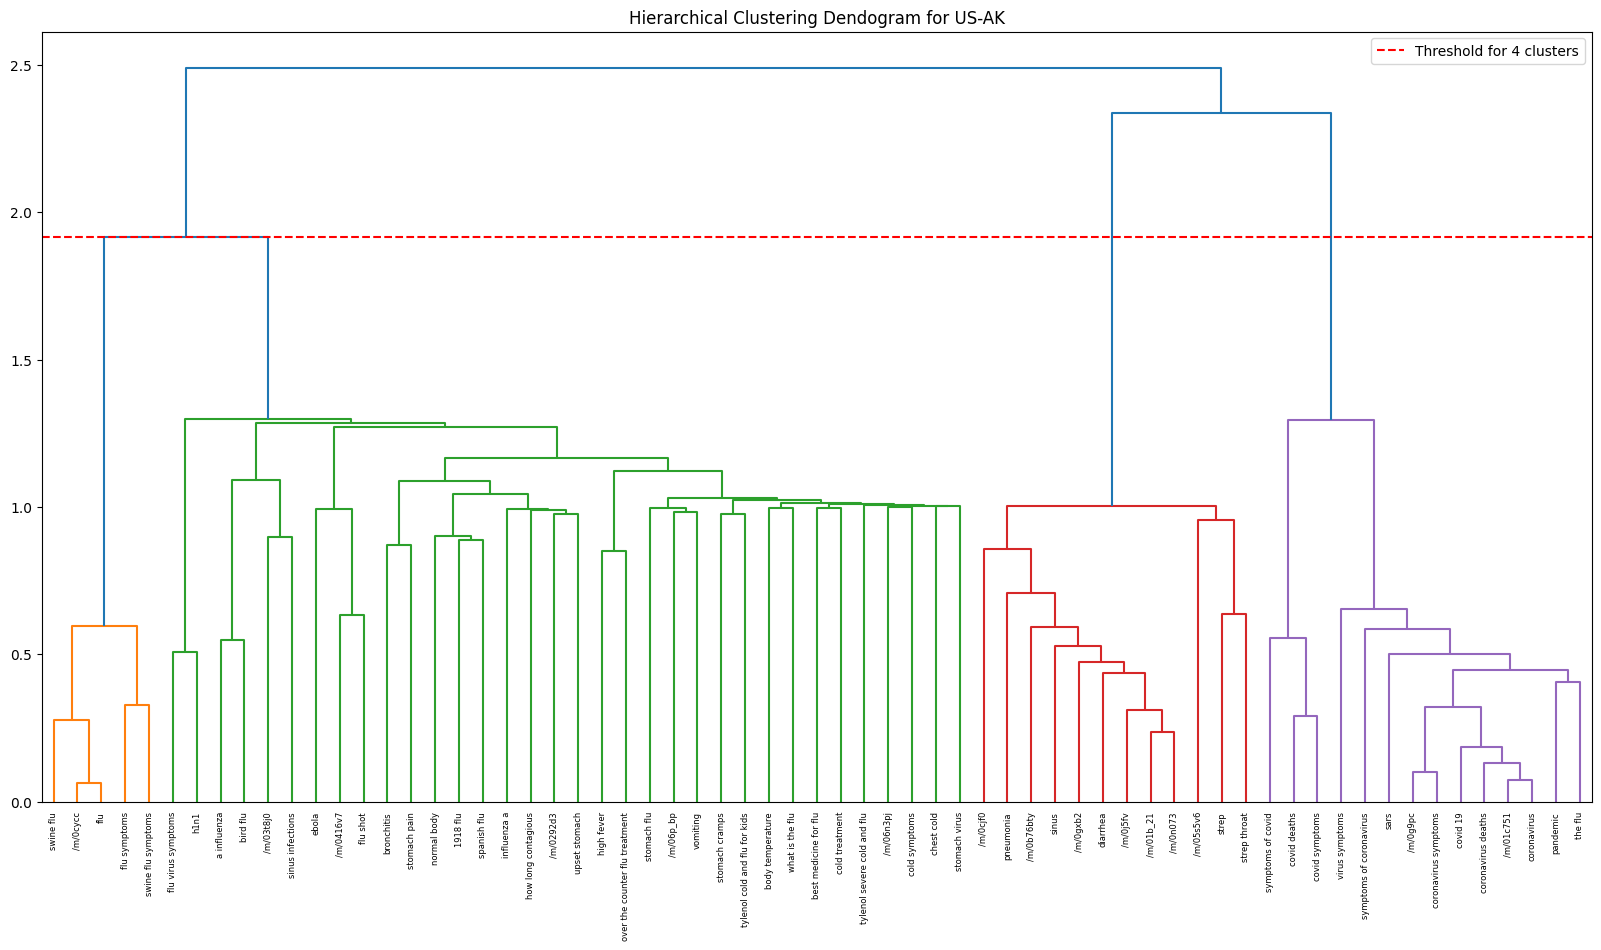

Number of clusters saved 4


In [17]:
filename = files[1]
# retrieving location
state = filename.split('_')[0]
print(state) 
# retrieving individual data
data = pd.read_csv(f'{directory}{filename}')
data = data.iloc[:data.shape[0]-2,:] # removing rows because NA
# removing "US-state_" from column names if need be
data.columns = [col.replace(f"{state}_", '') for col in data.columns]
data.columns = [col.replace('(TOPIC)', '/m/') for col in data.columns]
data

# removing columns that have all zeros
all_zero_columns = data.columns[(data == 0).all()]
# print(all_zero_columns)
data = data.iloc[:,1:].drop(columns=all_zero_columns)

# removing duplicate columns
corrs = data.corr()
# finding pairs of columns with corr = 1
perf_corrs = (corrs > 0.99) & (corrs != 0)
# extracting pairs of column names
perf_corr_pairs = [(col1, col2) for col1 in corrs.columns for col2 in corrs.columns 
                      if perf_corrs.loc[col1, col2] and col1 != col2]
columns_to_drop = set()
for col1 in corrs.columns:
    for col2 in corrs.columns:
        if perf_corrs.loc[col1, col2] and col1 != col2:
            columns_to_drop.add(col2)
data = data.drop(columns=columns_to_drop)

# missing values
perc = data.isin([0]).sum()/data.shape[0]*100
bins = list(range(0, 101, 10))
binned_perc = pd.cut(perc, bins=bins, right=False, include_lowest=True)
# number of columns in each bin
counts = binned_perc.value_counts().sort_index()
counts_df = counts.reset_index()
counts_df.columns = ['Percentage of zeros', 'Number of terms']
counts_df

# data visualization
plt.figure(figsize=(6, 3))
barplot = sns.barplot(x='Percentage of zeros', y='Number of terms', data=counts_df)
# adding actual number of terms above each bar
for index, row in counts_df.iterrows():
    barplot.text(index, row['Number of terms'], round(row['Number of terms'], 2), color='black', ha="center")

plt.xlabel('Percentage of Zeros')
plt.ylabel('Number of Terms')
plt.title(f'Percentage of Zeros per Term ({state})')
plt.xticks(rotation=45)
plt.show()

# removing terms with too many and too few zeros
most_zeros = perc[perc > 99.2].index
least_zeros = perc[perc <= 30].index
print("Terms with <30% of zeros", least_zeros.values)
cleaned = data.drop(columns=least_zeros) # dropping columns with <= 30% of zeros
cleaned = cleaned.drop(columns=most_zeros) # dropping columns with > 99% of zeros
print('Number of features:', cleaned.shape[1])

# saving individual terms with <= 30% of zeros into text file, they will be used as individual predictors
# create text file for each location
with open(f'../../data/02_intermediate/individual_terms/{state}_terms.txt', 'w') as file:
    for term in least_zeros.values:
        file.write(term + '\n')

df = cleaned
df = df.T
# correlation as similarity metric
corr_matrix = df.T.corr()
corr_distance = 1 - corr_matrix
# converting correlation distance into condensed distance matrix
condensed_corr_distance = squareform(corr_distance)
# some values are negative and close to zero, like -2.22044605e-16 
condensed_corr_distance[condensed_corr_distance < 0] = 0 

# Elbow method
# WCSS for each number of clusters from 1 to max_clusters
def calculate_wcss_and_centers(Z, max_clusters):
    wcss = []
    all_cluster_centers = []
    for n_clusters in range(1, max_clusters + 1):
        clusters = fcluster(Z, n_clusters, criterion='maxclust')
        cluster_centers = np.array([df[clusters == i].mean(axis=0) for i in range(1, n_clusters + 1)])
        cluster_distances = np.array([np.sum((df[clusters == i] - cluster_centers[i-1])**2) for i in range(1, n_clusters + 1)])
        wcss.append(np.sum(cluster_distances))
        all_cluster_centers.append(cluster_centers)
    return wcss, all_cluster_centers

# hierarchical clustering
linkage_matrix = linkage(condensed_corr_distance, method='ward')
max_clusters = 20
# computing Elbow
wcss, all_cluster_centers = calculate_wcss_and_centers(linkage_matrix, max_clusters)

# plotting the Elbow
plt.figure(figsize=(6, 4))
plt.plot(range(1, max_clusters + 1), wcss, marker='o')
plt.title(f'Elbow Method for {state}')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, max_clusters + 1))
plt.show()

# applying Kneedle Algorithm to find the elbow
kneedle = KneeLocator(range(1, max_clusters + 1), wcss, curve='convex', direction='decreasing')
elbow_point = kneedle.elbow
print(f'The elbow point is at cluster number: {elbow_point}')
# sizes of clusters from elbow
# num_clusters = elbow_point
# or define the elbow point manually from visualization
num_clusters = 4

# choosing number of clusters found by Elbow
clusters = fcluster(linkage_matrix, num_clusters, criterion='maxclust')

# table showing the number of terms per cluster
cluster_counts = pd.Series(clusters).value_counts().sort_index()
cluster_counts_df = pd.DataFrame({'Cluster': cluster_counts.index, 'Number of terms': cluster_counts.values})
print(cluster_counts_df.T)

# finding the appropriate distance threshold for the number of clusters
# i.e. finding the maximum distance that results in the desired number of clusters
linkage_matrix = linkage(condensed_corr_distance, method='ward')
threshold_distance = np.max(linkage_matrix[-(num_clusters-1), 2])
# final dendogram
plt.figure(figsize=(20,10))
dendro = dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90, color_threshold=threshold_distance)
plt.axhline(y=threshold_distance, color='r', linestyle='--', label=f'Threshold for {num_clusters} clusters')
plt.legend()
plt.title(f'Hierarchical Clustering Dendogram for {state}')
plt.show()

# creating a text file to obtain the list of terms
time_series_clusters = pd.DataFrame({'Time Series': df.index, 'Cluster': clusters})
clusters_dict = time_series_clusters.groupby('Cluster')['Time Series'].apply(list).to_dict()

# filtering clusters with size < 90 (larger clusters won't be able to be retrieved from Google Trends)
filtered_clusters_dict = {cluster_id: time_series_list for cluster_id, time_series_list in clusters_dict.items()
                          if len(time_series_list) < 90}
print('Number of clusters saved', len(filtered_clusters_dict))

In [ ]:
# writing the filtered clusters to a text file
# create text file for each location
file_path = f'../../data/02_intermediate/hierarchical_clusters/{state}_hierarchical.txt'
with open(file_path, 'w') as file:
    for cluster_id, time_series_list in filtered_clusters_dict.items():
        cluster_str = " + ".join(map(str, time_series_list)) + "\n"
        file.write(cluster_str)

In [13]:
pd.read_csv(file_path, header = None)

,0
0,/m/0cycc + flu + flu symptoms + swine flu + sw...
1,/m/0292d3 + /m/03t8j0 + /m/0416v7 + /m/06n3pj ...
2,/m/01b_21 + /m/05s5v6 + /m/0b76bty + /m/0cjf0 ...
3,/m/01c751 + /m/0g9pc + coronavirus + coronavir...


## If there is a large cluster

If a single cluster remains disproportionately large compared to the others, we apply a second round of hierarchical clustering to further
subdivide it. 

In [ ]:
print('number of large clusters', cluster_counts[cluster_counts >= 90].index.shape)
cluster_counts[cluster_counts >= 90].index[0]

In [ ]:
# indicating index of large cluster
ind = cluster_counts[cluster_counts >= 90].index[0] 
print("large cluster index", ind)
large_cluster_indices = time_series_clusters[time_series_clusters['Cluster'] == ind].index
large_cluster_data = df.iloc[large_cluster_indices, :]

# correlation matrix for the large cluster
large_cluster_corr_matrix = large_cluster_data.T.corr()
# correlation distance
large_cluster_distance_matrix = 1 - large_cluster_corr_matrix
link = squareform(large_cluster_distance_matrix)
# hierarchical clustering on large cluster
large_cluster_linkage = linkage(link, method='ward')

# Elbow to find optimal number of clusters
def calculate_wcss(Z, max_clusters):
    wcss = []
    for n_clusters in range(1, max_clusters + 1):
        clusters = fcluster(Z, n_clusters, criterion='maxclust')
        cluster_centers = np.array([large_cluster_data[clusters == i].mean(axis=0) for i in range(1, n_clusters + 1)])
        cluster_distances = np.array([np.sum((large_cluster_data[clusters == i] - cluster_centers[i-1])**2) for i in range(1, n_clusters + 1)])
        wcss.append(np.sum(cluster_distances))
    return wcss

large_cluster_linkage = linkage(link, method='ward')
max_clusters = 20 
wcss = calculate_wcss(large_cluster_linkage, max_clusters)

# plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_clusters + 1), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_clusters + 1))
plt.show()

# applying Kneedle Algorithm to find the elbow
kneedle = KneeLocator(range(1, max_clusters + 1), wcss, curve='convex', direction='decreasing')
elbow_point = kneedle.elbow
print(f'The elbow point is at cluster number: {elbow_point}')
num = elbow_point # number of clusters within large cluster
# or define the elbow point manually from visualization
# num = 7
large_cluster_linkage = linkage(link, method='ward')
sub_clusters = fcluster(large_cluster_linkage, num, criterion='maxclust')

# table showing the number of time series per cluster
sub_cluster_counts = pd.Series(sub_clusters).value_counts().sort_index()
sub_cluster_counts_df = pd.DataFrame({'Cluster': sub_cluster_counts.index, 'Number of terms': sub_cluster_counts.values})
print(sub_cluster_counts_df)

# finding the appropriate distance threshold for the number of clusters
# i.e. finding the maximum distance that results in the desired number of clusters
threshold_distance = np.max(large_cluster_linkage[-(num-1), 2])
plt.figure(figsize=(20, 10))
dendro = dendrogram(large_cluster_linkage, labels=large_cluster_data.index, leaf_rotation=90, color_threshold=threshold_distance)
plt.axhline(y=threshold_distance, color='r', linestyle='--', label='Threshold for 4 clusters')
plt.legend()
plt.title('Dendrogram for Large Cluster')
plt.show()

large_ts_clusters = pd.DataFrame({'Time Series': large_cluster_data.index, 'Cluster': sub_clusters})
large_clusters_dict = large_ts_clusters.groupby('Cluster')['Time Series'].apply(list).to_dict()

large_filtered = {cluster_id: time_series_list for cluster_id, time_series_list in large_clusters_dict.items()
                          if len(time_series_list) < 90}
print('Number of clusters saved', len(large_filtered))

In [ ]:
# appending the remaining clusters to the same file
with open(file_path, 'a') as file:
    for cluster_id, time_series_list in large_filtered.items():
        cluster_str = " + ".join(map(str, time_series_list)) + "\n"
        file.write(cluster_str)

In [ ]:
pd.read_csv(file_path, header = None)